# Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

In [103]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

from PIL import Image, ImageDraw

from pathlib import Path
from copy import deepcopy
import json

import matplotlib.pyplot as plt
# __________end of block__________

In [102]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________
# do not change the code in the block below
# __________start of block__________

#!wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt

with open('onegin.txt', 'r', encoding='utf-8') as iofile:
    text_input = iofile.readlines()

text_input = "".join([x.replace('\t\t', '').lower() for x in text_input])
# __________end of block__________
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text_input.lower())) + ['<sos>', '<eos>']
num_tokens = len(tokens)

assert num_tokens == 85, "Check the tokenization process"


print("OK")

# __________end of block__________
print(text_input[:35])

cpu device is available
OK

i

«мой дядя самых честных правил,


### за дело

чем заняться:
0. другой лабой
1. прикруткой нлп
2. изменением простейшей рнн
3. изобразить активацию !!!
4. покрутить колво нейронов и сравнить
5. клиппинг
6. разобраться, откуда беруться стихи типа аааааа или вхвхвхвхв или даже (на 200 было) периода 4 со вставкой рандомной буквы между ними
7. зачем нужна активация всё таки?

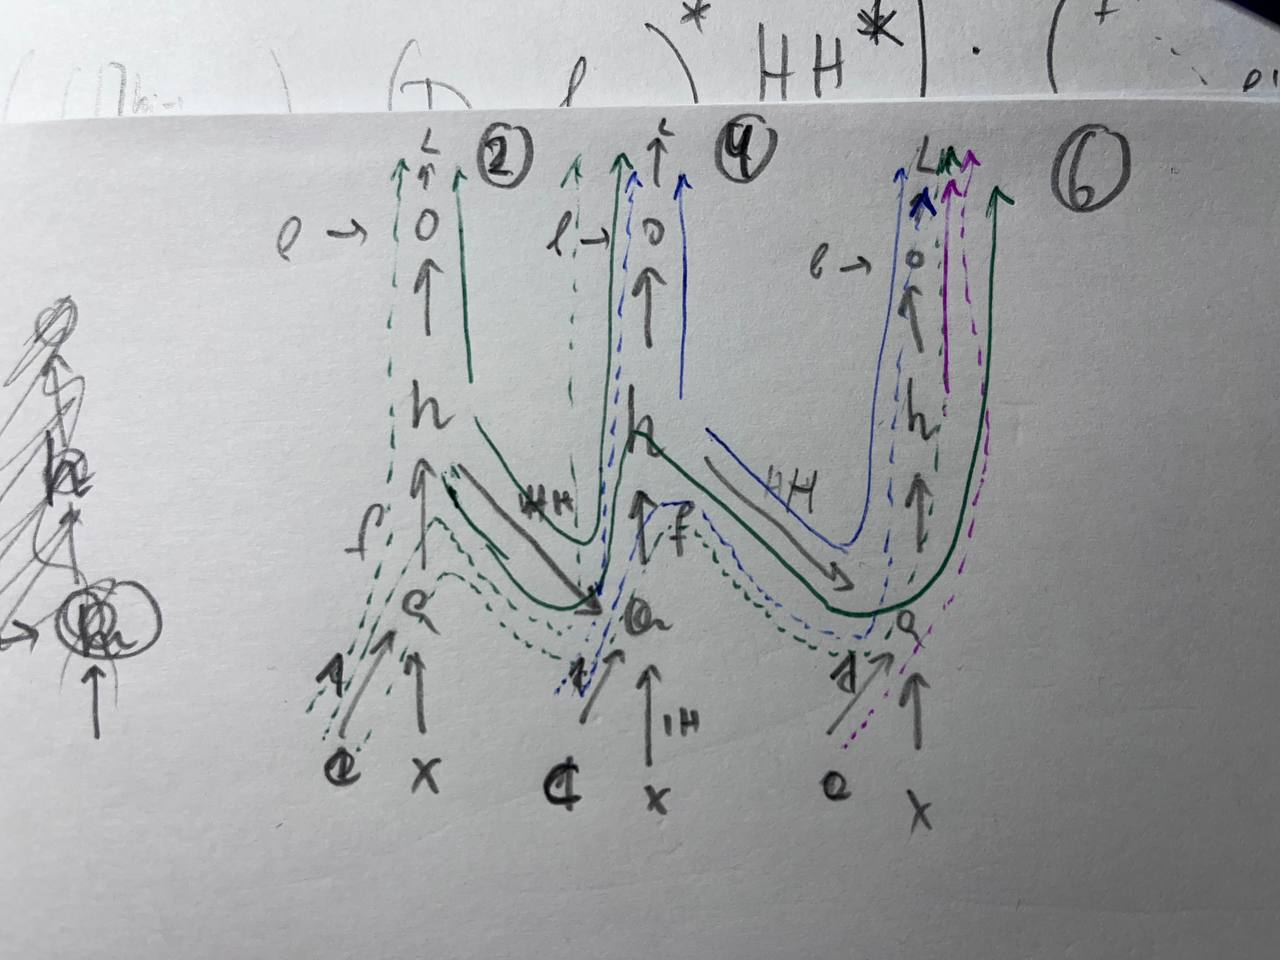

In [174]:
from IPython.display import Image

unfold = Image('unfold.jpg')
display(unfold)

In [93]:
import importlib
import srnn_class as my

In [129]:
importlib.reload(my)

my.SimplestRNN([0,0]).hi()

hi!!


In [219]:
from PIL import Image, ImageDraw, ImageFont

image = Image.new('RGB', (631, 64), color=(255,255,255))
drawer = ImageDraw.Draw(image)
font = ImageFont.truetype("UbuntuMono-Bold.ttf", 15, encoding='UTF-8')
# draw.text((10, 10), str) -- ошибка

drawer.text((20, 20), 'привет hello', fill=(255, 0,0), font=font)
drawer.text((20, 30), 'Hello', fill=(0,0, 255))
# step down is 10
# so is step left 
#drawer.text((20, 40), 'H', fill=(255, 255, 255))
#drawer.text((27, 40), 'ello', fill=(255, 255, 255))
a = Path('a')
a.mkdir(exist_ok=True)
image.save(a / 'hello.bmp')


#### test

In [130]:
tokens = sorted(set(text_input.lower())) + ['<sos>', '<eos>']
num_tokens = len(tokens)

assert num_tokens == 85, "Check the tokenization process"


print("OK")

OK


In [242]:
importlib.reload(my)
srnn = my.SimplestRNN(tokens, neurons=10)
                    
srnn.fit(human_written_text=text_input, 
          learning_rate=0.1 
          , line_count=2000
          , line_length=25
          , iterations=1#5#0 # 30
)

Loss on iteration 0 is 185.7074388882908
34.15769857314977
Loss on iteration 100 is 112.10335791397098
17.579657027703547
Loss on iteration 200 is 102.10364820664074
18.354777235445255
Loss on iteration 300 is 83.84850634342274
17.503986578786723
Loss on iteration 400 is 91.96384473692372
21.835998058988793
Loss on iteration 500 is 97.10087233624
18.837730826133612
Loss on iteration 600 is 89.72368863210055
21.496718602981012
Loss on iteration 700 is 87.10841188489154
19.17404113895158
Loss on iteration 800 is 76.2814989682114
21.806529801422222
Loss on iteration 900 is 90.03143301726952
19.643564120354043
Loss on iteration 1000 is 83.84820762154658
22.25022201171882
Loss on iteration 1100 is 84.21495400763129
20.25658535418875
Loss on iteration 1200 is 90.46858347132697
16.588742857013766
Loss on iteration 1300 is 93.74068712827412
22.26170202602434
Loss on iteration 1400 is 69.16371298314654
13.58121503579733
Loss on iteration 1500 is 68.46526058275799
20.000208001784713
Loss on iter

In [243]:
print(''.join(srnn.generate("мой дядя самых честных правил\nэнцефалит")))

мой дядя самых честных правил
энцефалитеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттететтеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттететтеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттететтеттеттеттеттеттеттеттеттеттеттеттеттеттет


In [244]:

print(''.join(srnn.generate("энцефалит", max_length=200)))

энцефалитеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттететтеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттететтеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттеттететтеттеттеттеттеттеттеттеттеттеттеттеттеттет


In [246]:
srnn.image.width

6511

In [240]:
srnn.image.image.show()
srnn.image.image.save(a / 'hello.bmp')

AttributeError: 'SimplestRNN' object has no attribute 'image'

In [245]:
srnn.visualize_activation("энцефалит")

In [230]:
srnn.visualize_activation( "мой дядя самых честных правил\nэнцефалит", max_length=500)

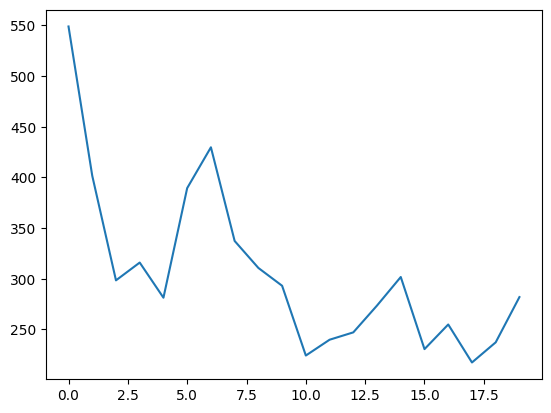

In [96]:
plt.plot(srnn.loss_history)

ПРОБЛЕМА: иногда обучается генерировать тупа один символ. надо псомтреть чо там за семплы
у Карпатого вроде нет такой проблемы, наверное это я

ГИПОТЕЗА: огромный лосс даёт огромный градиент даёт бесконечности в параметрах дают победу одной вероятности над всеми остальными. Наверное Карпатого спасает клиппирование, а не обнуление, тк он последнее не делает 

давайте посмотрим чо там


#### misc

#### advanced

Что можно сделать:

0. Просто рнн символ-в-символ
1. По строке выдавать символ
2. Поменять лосс
3. попробовать обучиться на тексте с ошибками (вряд ли разница будет заметна, но всё же. хотя бы попробовать рифму). ван хот кодирование это позволяет делать без изменения кода

In [ ]:
class TorchRNN:
    pass

In [ ]:
class StrangeRNN:
    def __init__(self, 
                 terminator=1000000):
        self.terminator = terminator

    def fit(self,
            text, token_to_idx, 
    ):
        # dirty
        self.text_encoded = [token_to_idx[x] for x in text]
        words = text.split()
        lens = np.array(list(map(len, words)))

        # to track pairs of words, len should equal len of a single word
        # thus it will match ending of one word with start of another
        # TODO compare to double len. In that case we would track
        # triples of words 
            # TODO check if we believe that lens of coherent words are independent :))))
        # with a single word accounted for quite a lot of times. An effect I find 
        # negative, since a very well (or poorly)-generated word might 
        # overshadow coherence loss
        self.loss_tuple_len = np.round(lens.mean()) + 2 # 7 for whole onegin.txt
        self.text_tuplified = self.tuplify(text)
        
        # fitting itself



    def generate(self, seed_phrase=None, max_length=200, temperature=1.0):
        pass

    # DO I NEED THIS?
    def tuplify(self, seq):
        n = len(seq)
        seq += [self.terminator] * self.loss_tuple_len
        tuplified = np.array([seq[i:i + self.loss_tuple_len] for i in range(n)])
        # TODO cherry pick tuples?
        return tuplified

    def tuple_loss(self, output):
        # should not use 1NN to find closest tuple in text
        # because my tokens are not embedded
            # TODO although letters can be embedded
        # use just Levenstein distance instead
        # TODO prohibit technical tokens, or just ignore them at detokenization :)))
        L = 0.0
        output_tuplified = self.tuplify(output)

        # TODO vectorize
        for tup in output_tuplified:
            matches = (tup == output_tuplified).astype(int).sum(axis=1)
            L += (self.loss_tuple_len - np.max(matches)) 
        
        return L / (self.loss_tuple_len * len(output_tuplified))
    


В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

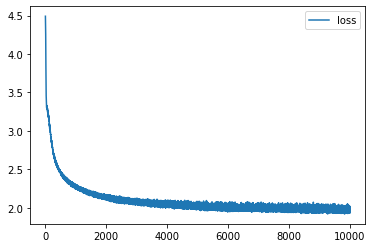

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [ ]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''

    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else:
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)

    #feed the seed phrase, if any

    # your code here

    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [ ]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

<sos> мой дядя самых честных правилас;



xiv

но как потокой.



xii

«я свобред не словавран в скорей,
для с посвялесь мне моловой,
те ты,
перегиной в тям праздной
и привезут перваю вся вновся сквозь ти стала сблился,
и старый свимарной таня обратель любова не когда и нет волностье нежной
тишен,
перестоком.
«поже постаничив очествы
в и старько забаньем и заковенью,
ее своя моднать наводушта;
какой нет поли своем горозный и быле и, законно он ходушних недважный плая
с за стра.



xvii




xxvi

все 


In [ ]:
seed_phrase = ' мой дядя самых честных правил'

In [ ]:
generated_phrases = # your code here

# For example:

# generated_phrases = [
#     generate_sample(
#         model,
#         ' мой дядя самых честных правил',
#         max_length=500,
#         temperature=1.
#     ).replace('<sos>', '')
#     for _ in range(10)
# ]

In [ ]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'


submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

На этом задание завершено. Поздравляем!

# На всём готовеньком
https://gist.github.com/karpathy/d4dee566867f8291f086

In [73]:
karpathy_loss = []

In [86]:
"""
Minimal character-level Vanilla RNN model. Written by Andrej Karpathy (@karpathy)
BSD License
"""
import numpy as np

# data I/O
data = open('onegin.txt', 'r', encoding='utf-8').read() # should be simple plain text file
chars = list(set(data))
data_size, vocab_size = len(data), len(chars)
char_to_ix = { ch:i for i,ch in enumerate(chars) }
ix_to_char = { i:ch for i,ch in enumerate(chars) }

# hyperparameters
hidden_size = 100 # size of hidden layer of neurons
seq_length = 25 # number of steps to unroll the RNN for
learning_rate = 1e-1

# model parameters
Wxh = np.random.randn(hidden_size, vocab_size)*0.01 # input to hidden
Whh = np.random.randn(hidden_size, hidden_size)*0.01 # hidden to hidden
Why = np.random.randn(vocab_size, hidden_size)*0.01 # hidden to output
bh = np.zeros((hidden_size, 1)) # hidden bias
by = np.zeros((vocab_size, 1)) # output bias

def lossFun(inputs, targets, hprev):
  """
  inputs,targets are both list of integers.
  hprev is Hx1 array of initial hidden state
  returns the loss, gradients on model parameters, and last hidden state
  """
  xs, hs, ys, ps = {}, {}, {}, {}
  hs[-1] = np.copy(hprev)
  loss = 0
  # forward pass
  for t in range(len(inputs)):
    xs[t] = np.zeros((vocab_size,1)) # encode in 1-of-k representation
    xs[t][inputs[t]] = 1
    hs[t] = np.tanh(np.dot(Wxh, xs[t]) + np.dot(Whh, hs[t-1]) + bh) # hidden state
    ys[t] = np.dot(Why, hs[t]) + by # unnormalized log probabilities for next chars
    ps[t] = np.exp(ys[t]) / np.sum(np.exp(ys[t])) # probabilities for next chars
    loss += -np.log(ps[t][targets[t],0]) # softmax (cross-entropy loss)
  # backward pass: compute gradients going backwards
  dWxh, dWhh, dWhy = np.zeros_like(Wxh), np.zeros_like(Whh), np.zeros_like(Why)
  dbh, dby = np.zeros_like(bh), np.zeros_like(by)
  dhnext = np.zeros_like(hs[0])
  for t in reversed(range(len(inputs))):
    dy = np.copy(ps[t])
    dy[targets[t]] -= 1 # backprop into y. see http://cs231n.github.io/neural-networks-case-study/#grad if confused here
    dWhy += np.dot(dy, hs[t].T)
    dby += dy
    dh = np.dot(Why.T, dy) + dhnext # backprop into h
    dhraw = (1 - hs[t] * hs[t]) * dh # backprop through tanh nonlinearity
    dbh += dhraw
    dWxh += np.dot(dhraw, xs[t].T)
    dWhh += np.dot(dhraw, hs[t-1].T)
    dhnext = np.dot(Whh.T, dhraw)
  for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
    np.clip(dparam, -5, 5, out=dparam) # clip to mitigate exploding gradients
  return loss, dWxh, dWhh, dWhy, dbh, dby, hs[len(inputs)-1]

def sample(h, seed_ix, n):
  """ 
  sample a sequence of integers from the model 
  h is memory state, seed_ix is seed letter for first time step
  """
  x = np.zeros((vocab_size, 1))
  x[seed_ix] = 1
  ixes = []
  for t in range(n):
    h = np.tanh(np.dot(Wxh, x) + np.dot(Whh, h) + bh)
    y = np.dot(Why, h) + by
    p = np.exp(y) / np.sum(np.exp(y))
    ix = np.random.choice(range(vocab_size), p=p.ravel())
    x = np.zeros((vocab_size, 1))
    x[ix] = 1
    ixes.append(ix)
  return ixes

param = None
n, param = 0, 0
mWxh, mWhh, mWhy = np.zeros_like(Wxh), np.zeros_like(Whh), np.zeros_like(Why)
mbh, mby = np.zeros_like(bh), np.zeros_like(by) # memory variables for Adagrad
smooth_loss = -np.log(1.0/vocab_size)*seq_length # loss at iteration 0
while True:
  # prepare inputs (we're sweeping from left to right in steps seq_length long)
  if param+seq_length+1 >= len(data) or n == 0: 
    hprev = np.zeros((hidden_size,1)) # reset RNN memory
    param = 0 # go from start of data
  inputs = [char_to_ix[ch] for ch in data[param:param+seq_length]]
  targets = [char_to_ix[ch] for ch in data[param+1:param+seq_length+1]]

  # sample from the model now and then
  if n % 100 == 0:
    sample_ix = sample(hprev, inputs[0], 200)
    txt = ''.join(ix_to_char[ix] for ix in sample_ix)
    print('--------------------------')
    print(txt)
    print('--------------------------')
    #print(hprev)

  # forward seq_length characters through the net and fetch gradient
  loss, dWxh, dWhh, dWhy, dbh, dby, hprev = lossFun(inputs, targets, hprev)
  smooth_loss = smooth_loss * 0.999 + loss * 0.001
  if n % 100 == 0: 
    karpathy_loss.append(loss)
    print(f'iter {n}, smooth loss: {smooth_loss}')   
    print(f'iter {n}, loss: {loss}')   

  # perform parameter update with Adagrad
  for param1, dparam, mem in zip([Wxh, Whh, Why, bh, by], 
                                [dWxh, dWhh, dWhy, dbh, dby], 
                                [mWxh, mWhh, mWhy, mbh, mby]):
    mem += dparam * dparam
    param1 += -learning_rate * dparam / np.sqrt(mem + 1e-8) # adagrad update

  param += seq_length # move data pointer
  n += 1 # iteration counter 

--------------------------
ъyп…РэiDъ—.МнDУиGлz]zШ	mзI)cspyvqЮIGС;…-и«gяБ.з!QшрT-Я,щэW…vkgNУПzП…ДiЗn»еfdУуsиlgBтTщ	Q(тbvЮTч7SФв7ьймfзшGЛoAшыр;[цошzз
ХyGаИыдъещPБЦюв.о9
П]блp rcиpау
сQLkКпcЯююa5-цхкц,дАs:bуQиКЯQъХzeHNе!T7Тк:Е…:dA
--------------------------
iter 0, smooth loss: 121.30074916057612
iter 0, loss: 121.29331918367801
--------------------------
ееее о мед р  аоокпг 	оя	яеме евяо	 клтиемжет
нтт мьтео омшо м а ,еноь м онодте оа ,,е оеме,хувмок, 	я,аЧ	мьмоо оТ о,яо ,о еио,т ш,ропн	я мзео,  х,?онв,жмн,ое ойонхеурсиям з  двон	 хонеяк,о	ноаея знДу
--------------------------
iter 100, smooth loss: 121.63631374108647
iter 100, loss: 94.79170741082011
--------------------------
кртый!. сн	мттдрам анил, випордяннк тытмне   дес  и дм втзч тежреенивьвт  то?й метД,
	
  
	
	Е тнк зевпйвгж теауммСсне чтрт  тTттзр в
 умн .вч Xян тмвекм тожннтж  с.пяаоы
о ию
ьт таж еет,аад; е,
ятПтН
--------------------------
iter 200, smooth loss: 118.50723335540715
iter 200, loss: 80.87344763659793
----------

KeyboardInterrupt: 

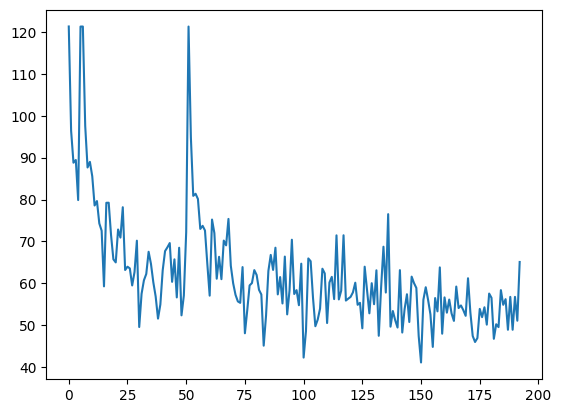

In [87]:
plt.plot(karpathy_loss)

# Наблюдения
1. Активация делает нейроны бинарными. https://www.deeplearningbook.org/contents/mlp.html около 632
2. Карпатый ПОЧЕМУ ТО не ресеттит спрятанное состояние после обновления параметров
3. КАЖЕТСЯ нейронка перестала генерировать один и тот же симывол когда я перестал рандомайзить начальное спрятанное. ИЛИ НЕТ  
4. Огромный лосс даёт длинный градиент, но вышагнуть из бесконечного лосса это не помогает, почему-то

вот стихи на 200 нейронах (learning_rate=0.1, 
          line_count=2000,
          line_length=25,
          iterations=3,
          reset_hid=on)
энцефалитждтттт,ии


ннноооезддттез<eos>зтт,,аии^vнннноппттсззzпттт–н )тгт
инооот
ннни  ттяннзь<eos>ттаvь е—тт
иpоо
ннннноое—тснз<sos>путт
и,о вптттб[wzееiт
иноооннннежпттт
,ио
нннонззззттр,, жж
гнннилзтттяаuaж птa<eos>зддтта,wztттт
иннооклнннежпттт,w<sos>tlттт
,
оорнннежептт
иинооонннежжптт]bнзепттwинооо
нннизжпттaнь уттwиаpоожннннзв—тт
иnиииннннн<sos>ьепттезз<eos>тт
ииио


а вот на 100 (learning_rate=0.1, 
          line_count=2000,
          line_length=25,
          iterations=10,
          reset_hid=on)

энцефалитлнет тсуев  медсу зю 
лаыатт пчв
ои
атлешо цтибви
мебат ыс дб
имдепчн
лапцот чалкстызт
я змыа,
оа
момны  т ыследшлныылоуб пумхырузй ыйуейыы сдна
остппасю
ок
ч
ча
та
иратетгиому баоиоп
 
шныдпбоий 
охо
